In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
import seaborn as sns
import seaborn.objects as so
import numpy as np
from lqg import xcorr
import arviz as az

from jax import random

plt.style.use("cppp.notebook")
theme = {**sns.axes_style("ticks"), **rcParams}
so.Plot.config.theme.update(theme)

from cppp.models.multisensory import MultisensoryDelayModel, UnisensoryDelayModel
from cppp.load import preprocess_multisensory_data, load_multisensory_data


## Load data

In [3]:

df = load_multisensory_data(base_path="../data")
df.head()

print(df["participant"].unique())

Multisensory DataFrame loaded from ../data/multisensory/df_downsampled.csv with shape: (15701, 9)
[135033060 212056115]


In [4]:
df.columns

Index(['session', 'participant', 'trial_number', 'type', 'vis_noise', 'time',
       'lefty_pos', 'righty_pos', 'cursory_pos'],
      dtype='object')

In [5]:
for condition in df["type"].unique():
    for vis_noise in df["vis_noise"].unique():
        print(condition, vis_noise)
        data = preprocess_multisensory_data(
                        df, participant=135033060, condition=condition, vis_noise=vis_noise
                    )
        print(data.shape)

vis 1
(8, 98, 2)
vis 2
(8, 166, 2)
multi 1
(8, 166, 2)
multi 2
(8, 166, 2)
prop 1
(8, 166, 2)
prop 2
(8, 166, 2)


## Plot some example trials

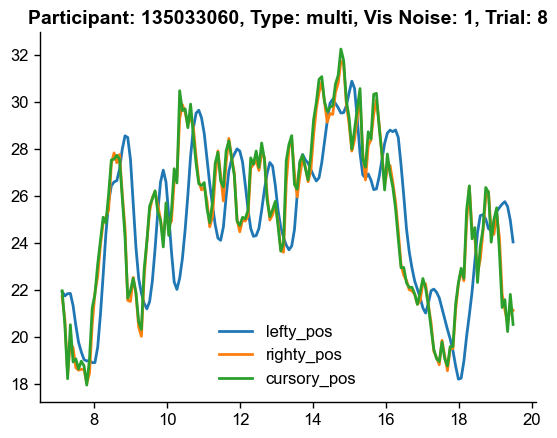

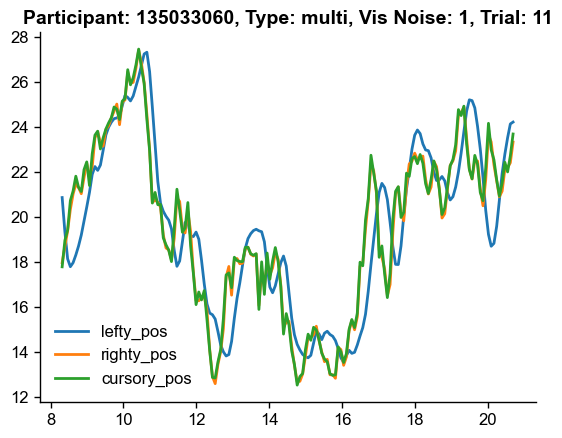

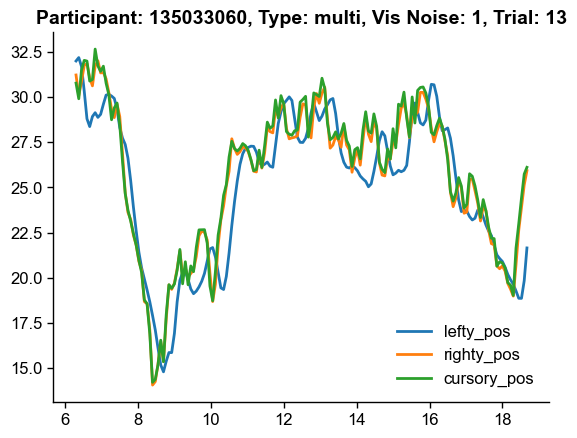

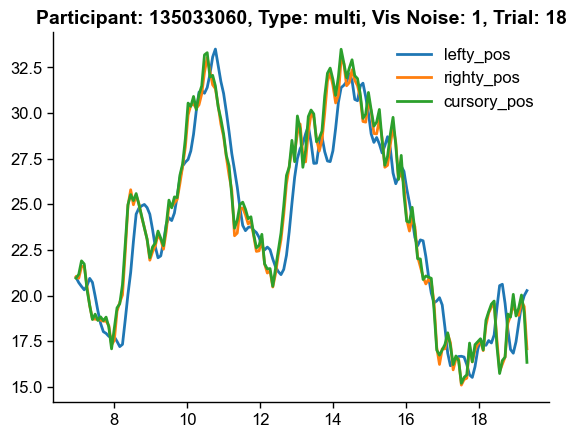

In [6]:
for i, (name, group) in enumerate(df.groupby(["participant", "type", "vis_noise", "trial_number"])):
    plt.plot(group["time"], group["lefty_pos"], label="lefty_pos")
    plt.plot(group["time"], group["righty_pos"], label="righty_pos")
    plt.plot(group["time"], group["cursory_pos"], label="cursory_pos")
    plt.title(f"Participant: {name[0]}, Type: {name[1]}, Vis Noise: {name[2]}, Trial: {name[3]}")
    plt.legend()
    plt.show()

    if i > 2:
        break

## Model fits

### Parameter estimates

In [7]:
delays = {"vis": 2, "prop": 1}
seed = 2

results = []
for participant in df["participant"].unique():
    for i, condition in enumerate(["multi", "vis", "prop"]):
        
        for j, vis_noise in enumerate([1, 2]):
            inference_data = az.from_netcdf(
                f"../results/multisensory-mcmc-{participant}-{condition}-{vis_noise}-{seed}.nc"
            )
            inference_data = inference_data.sel(chain=[0,1, 2, 3])
            summary = az.summary(inference_data)

            # Check if there are any parameters with r_hat > 1.1
            print(f"Participant: {participant}, Condition: {condition}, Vis Noise: {vis_noise}")
            print(summary["r_hat"].max())


            # If the condition is "vis" or "prop", we have a single sigma parameter. Otherwise, we have two sigma parameters (sigma_prop and sigma_vis).
            # Create a dataframe with columns: participant, condition, vis_noise, param, value (for clean visualization with seaborn)
            if condition in ["vis", "prop"]:
                for name in inference_data.posterior.data_vars:
                    results.append(pd.DataFrame({
                        "participant": participant,
                        "condition": condition,
                        "vis_noise": vis_noise,
                        "param": name if name != "sigma" else f"sigma_{condition}",
                        "value": inference_data.posterior[name].values.flatten(),
                    }))
            else:
                for name in inference_data.posterior.data_vars:
                    if name != "sigmas":
                        results.append(pd.DataFrame({
                            "participant": participant,
                            "condition": condition,
                            "vis_noise": vis_noise,
                            "param": name,
                            "value": inference_data.posterior[name].values.flatten(),
                        }))
                    else:
                        results.append(pd.DataFrame({
                            "participant": participant,
                            "condition": condition,
                            "vis_noise": vis_noise,
                            "param": "sigma_prop",
                            "value": inference_data.posterior["sigmas"].values[...,0].flatten(),
                        }))
                        results.append(pd.DataFrame({
                            "participant": participant,
                            "condition": condition,
                            "vis_noise": vis_noise,
                            "param": "sigma_vis",
                            "value": inference_data.posterior["sigmas"].values[...,1].flatten(),
                        }))

results_df = pd.concat(results).reset_index(drop=True)
results_df.head()

Participant: 135033060, Condition: multi, Vis Noise: 1
1.0
Participant: 135033060, Condition: multi, Vis Noise: 2
1.0
Participant: 135033060, Condition: vis, Vis Noise: 1
1.0
Participant: 135033060, Condition: vis, Vis Noise: 2
1.0
Participant: 135033060, Condition: prop, Vis Noise: 1
1.0
Participant: 135033060, Condition: prop, Vis Noise: 2
1.0
Participant: 212056115, Condition: multi, Vis Noise: 1
1.0
Participant: 212056115, Condition: multi, Vis Noise: 2
1.0
Participant: 212056115, Condition: vis, Vis Noise: 1
1.0
Participant: 212056115, Condition: vis, Vis Noise: 2
1.0
Participant: 212056115, Condition: prop, Vis Noise: 1
1.0
Participant: 212056115, Condition: prop, Vis Noise: 2
1.0


,participant,condition,vis_noise,param,value
0,135033060,multi,1,action_cost,0.022375
1,135033060,multi,1,action_cost,0.022409
2,135033060,multi,1,action_cost,0.022498
3,135033060,multi,1,action_cost,0.022756
4,135033060,multi,1,action_cost,0.020815


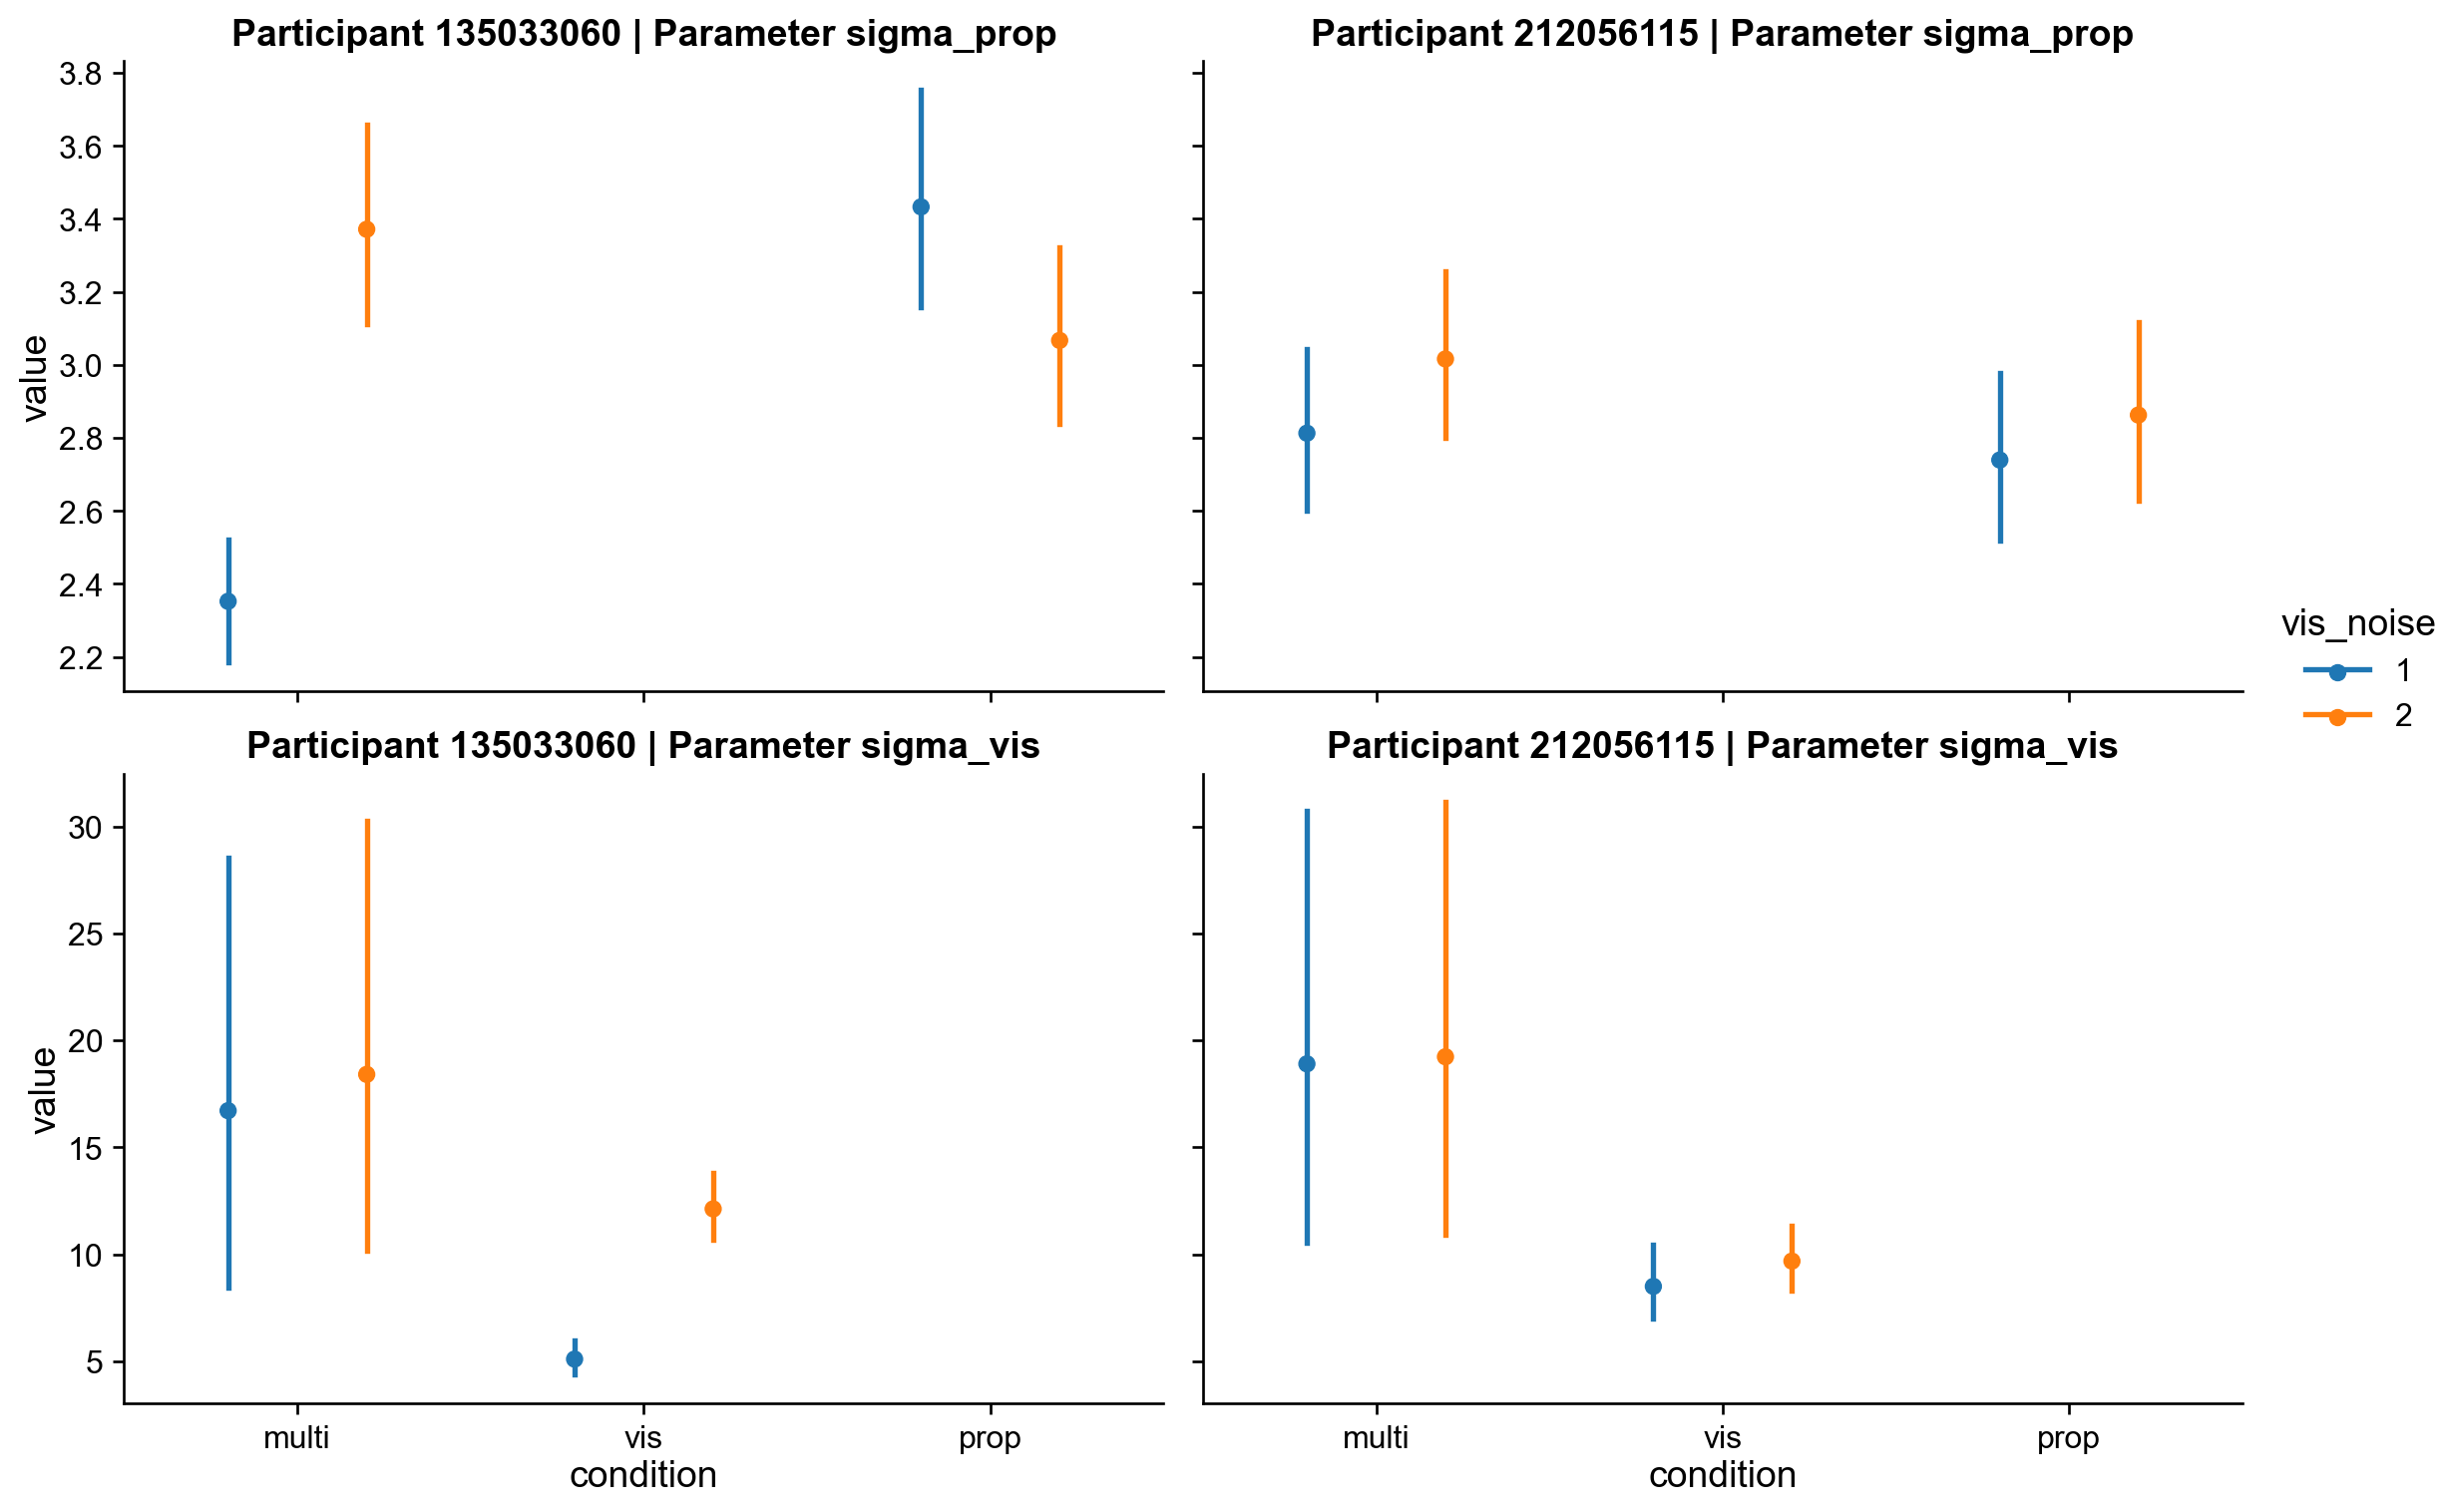

In [8]:
import seaborn.objects as so

(
    so.Plot(
        results_df[results_df["param"].str.contains("sigma")],
        x="condition",
        y="value",
        color="vis_noise",
        # marker="participant"
    )
    .add(so.Dot(), so.Agg(), so.Dodge())
    .add(so.Range(), so.Est(errorbar=("pi", 95)), so.Dodge())
    # .add(so.Line())
    .facet(row="param", col="participant")
    .scale(color=so.Nominal())
    .label(row="Parameter", col="Participant")
    .layout(size=(12, 8))
    .share(y="row")

)

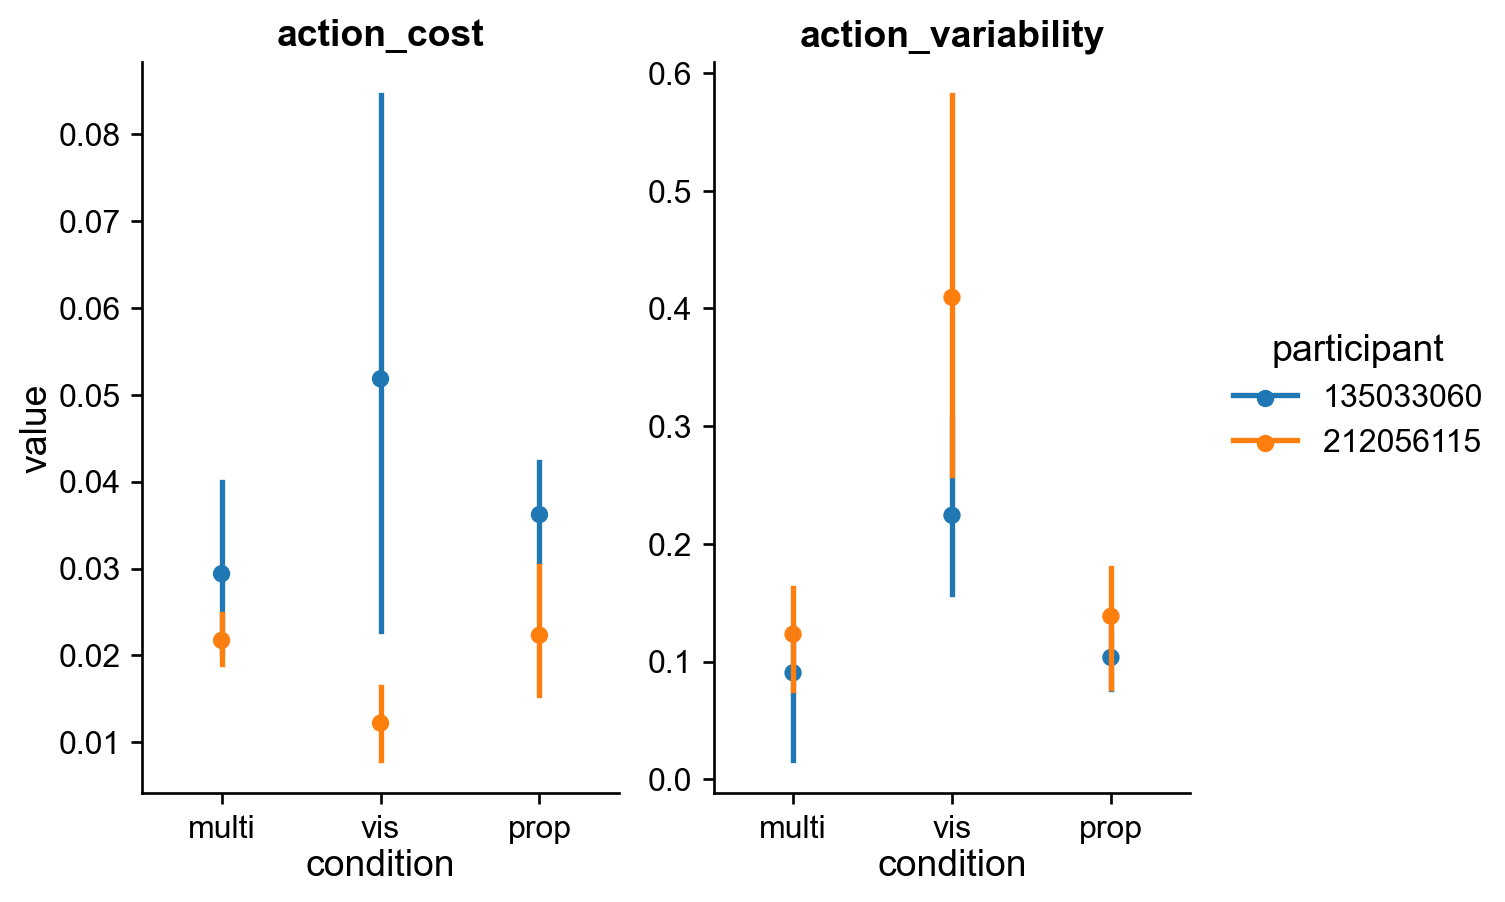

In [9]:
(
    so.Plot(
        results_df[~results_df["param"].str.contains("sigma")],
        x="condition",
        y="value",
        color="participant",
    )
    .add(so.Dot(), so.Agg())
    .add(so.Range(), so.Est(errorbar=("pi", 95)))
    # .add(so.Line())
    .facet(col="param")
    .scale(color=so.Nominal())
    .share(y=False)
)

### Simulated vs. empirical CCGs

Condition: multi, Vis Noise: 1
{'action_cost': 0.022, 'action_variability': 0.074, 'sigmas[0]': 2.352, 'sigmas[1]': 16.716}
Condition: multi, Vis Noise: 2
{'action_cost': 0.037, 'action_variability': 0.107, 'sigmas[0]': 3.372, 'sigmas[1]': 18.413}
Condition: vis, Vis Noise: 1
{'action_cost': 0.026, 'action_variability': 0.281, 'sigma': 5.104}
Condition: vis, Vis Noise: 2
{'action_cost': 0.077, 'action_variability': 0.167, 'sigma': 12.125}
Condition: prop, Vis Noise: 1
{'action_cost': 0.034, 'action_variability': 0.103, 'sigma': 3.433}
Condition: prop, Vis Noise: 2
{'action_cost': 0.039, 'action_variability': 0.104, 'sigma': 3.067}
Condition: multi, Vis Noise: 1
{'action_cost': 0.022, 'action_variability': 0.121, 'sigmas[0]': 2.813, 'sigmas[1]': 18.905}
Condition: multi, Vis Noise: 2
{'action_cost': 0.021, 'action_variability': 0.125, 'sigmas[0]': 3.016, 'sigmas[1]': 19.236}
Condition: vis, Vis Noise: 1
{'action_cost': 0.01, 'action_variability': 0.534, 'sigma': 8.503}
Condition: vis, V

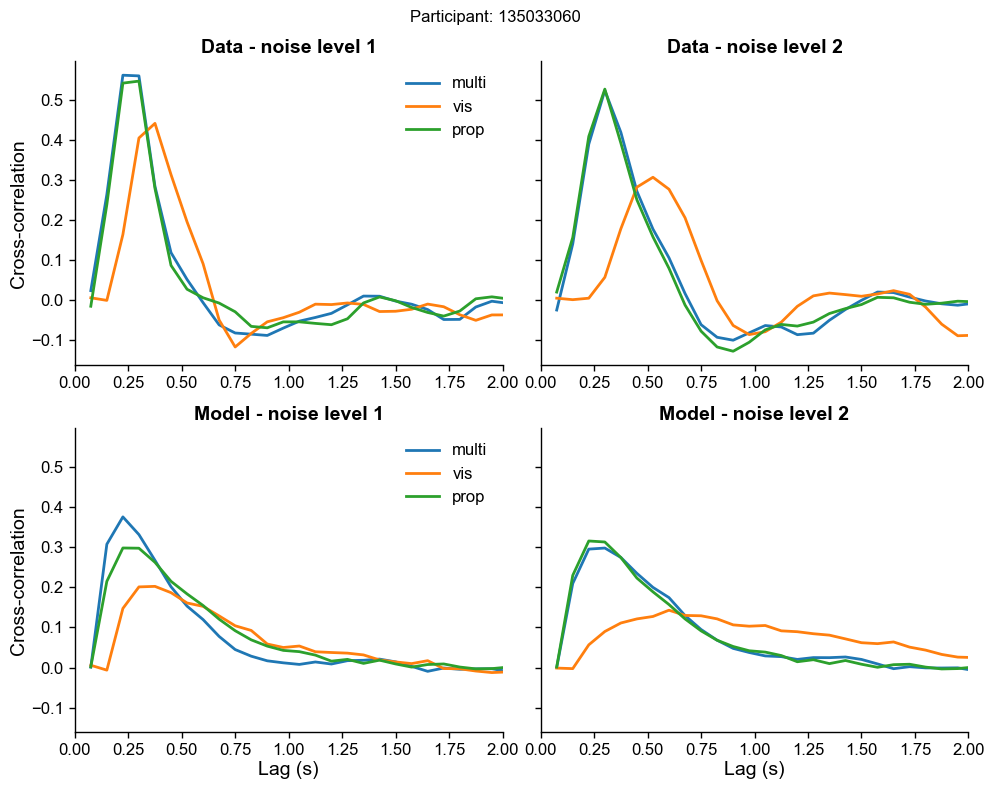

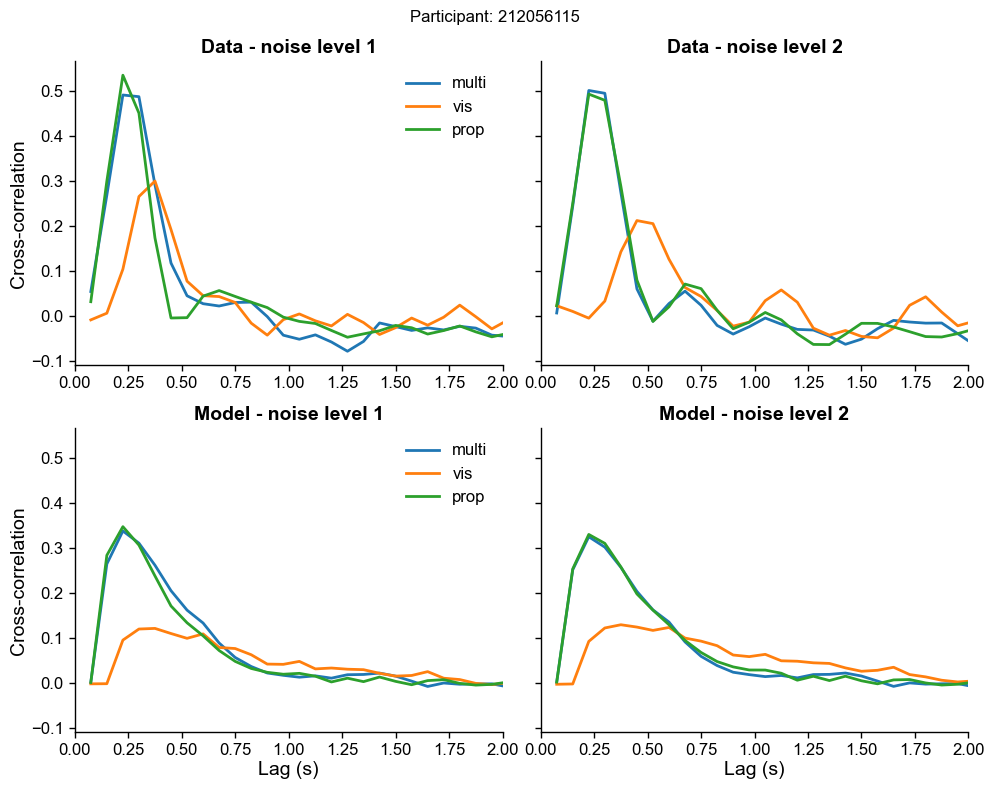

In [10]:
delays = {"vis": 2, "prop": 1}
seed = 2

for participant in df["participant"].unique():

    f, ax = plt.subplots(2, 2, figsize=(10, 8), sharey=True)
    for i, condition in enumerate(["multi", "vis", "prop"]):

        for j, vis_noise in enumerate([1, 2]):
            # preprocess the data for this participant, condition, and noise level
            data = preprocess_multisensory_data(
                df, participant=participant, condition=condition, vis_noise=vis_noise
            )

            # read in the inference results for this participant, condition, and noise level
            inference_data = az.from_netcdf(
                f"../results/multisensory-mcmc-{participant}-{condition}-{vis_noise}-{seed}.nc"
            )
            summary = az.summary(inference_data)            

            # get posterior mean
            posterior_mean = summary["mean"].to_dict()
            print(f"Condition: {condition}, Vis Noise: {vis_noise}")
            print(posterior_mean)

            # create model with posterior mean parameters (note that we have to rename the sigmas parameters for the multisensory model)
            if condition == "multi":
                posterior_mean["sigmas"] = [
                    posterior_mean.pop("sigmas[0]"),
                    posterior_mean.pop("sigmas[1]"),
                ]
                model = MultisensoryDelayModel(
                    **posterior_mean,
                    T=data.shape[1],
                    delays=[delays["prop"], delays["vis"]],
                    dt=0.075,
                    process_noise=1.2,
                )
            else:
                model = UnisensoryDelayModel(
                    **posterior_mean,
                    T=data.shape[1],
                    delay=delays[condition],
                    dt=0.075,
                    process_noise=1.2,
                )

            # TODO: generate prediction for multisensory condition from unisensory model fits

            # simulate data from the model and compute cross-correlation of velocities for both the simulated data and the real data
            sim_data = model.simulate(rng_key=random.PRNGKey(0), n=100)
            sim_vels = np.diff(sim_data, axis=1)
            lags, sim_correls = xcorr(sim_vels[:, :, 1], sim_vels[:, :, 0], maxlags=50)

            
            vels = np.diff(data, axis=1)
            lags, correls = xcorr(vels[:, :, 1], vels[:, :, 0], maxlags=50)

            # plot the cross-correlations for the real data and the simulated data
            ax[0, j].plot(
                lags[51:] * 0.075, correls.mean(axis=0)[51:], label=f"{condition}"
            )
            ax[1, j].plot(
                lags[51:] * 0.075, sim_correls.mean(axis=0)[51:], label=f"{condition}"
            )

            ax[0, j].set_xlim(0, 2)
            ax[1, j].set_xlim(0, 2)

            ax[0, j].set_title(f"Data - noise level {vis_noise}")
            ax[1, j].set_title(f"Model - noise level {vis_noise}")

    ax[1, 0].set_xlabel("Lag (s)")
    ax[1, 1].set_xlabel("Lag (s)")
    ax[0, 0].set_ylabel("Cross-correlation")
    ax[1, 0].set_ylabel("Cross-correlation")

    ax[0, 0].legend()
    ax[1, 0].legend()
    f.suptitle(f"Participant: {participant}")
    f.tight_layout()

## Joint model

In [16]:
participant = 135033060
# participant = 212056115
models = {model_name: az.from_netcdf(
                f"../results/multisensory-mcmc-{participant}_1_2_1_2500_2500_4_None_{model_name}.nc"
            )
            for model_name in ["optimal", "no_integration", "equal_integration"]}

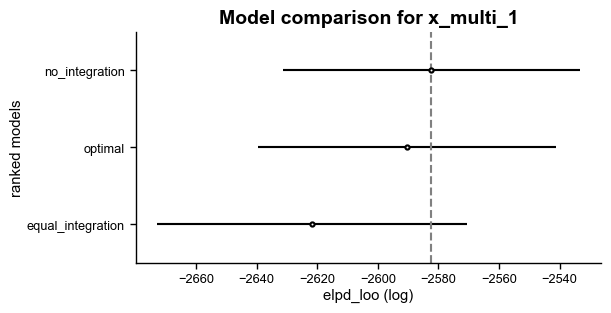

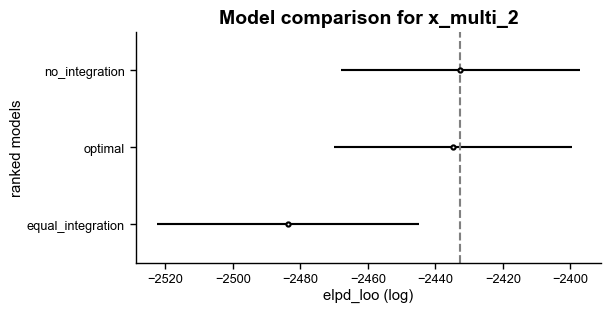

In [17]:
for var_name in ["x_multi_1", "x_multi_2"]:

    comp_df = az.compare(models, var_name=var_name)
    axes = az.plot_compare(comp_df=comp_df)
    axes.set_title(f"Model comparison for {var_name}")

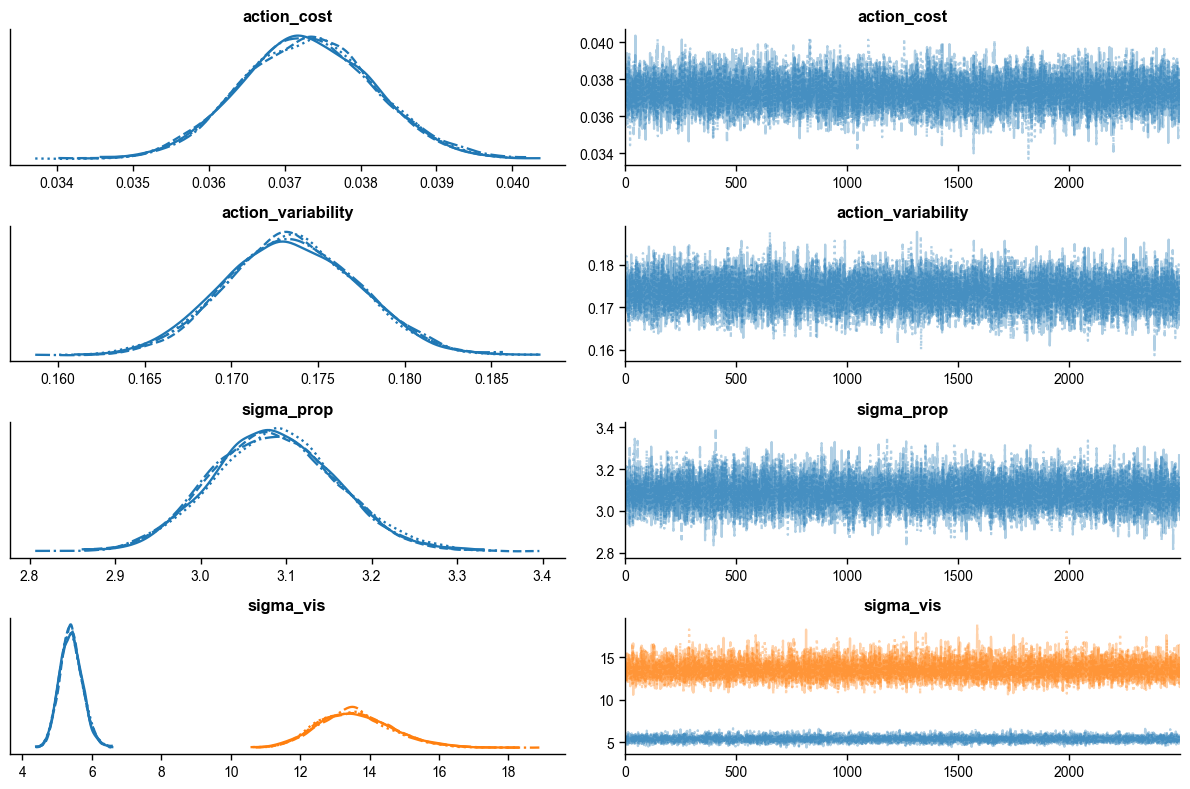

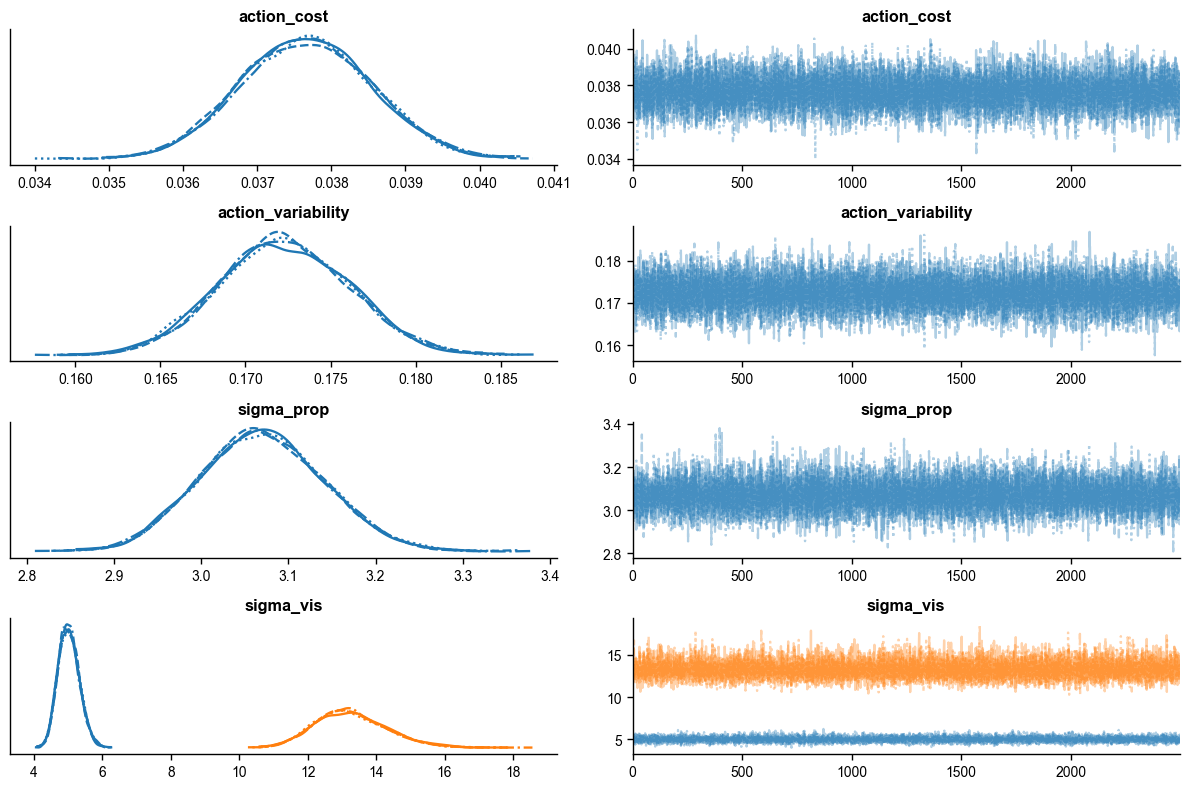

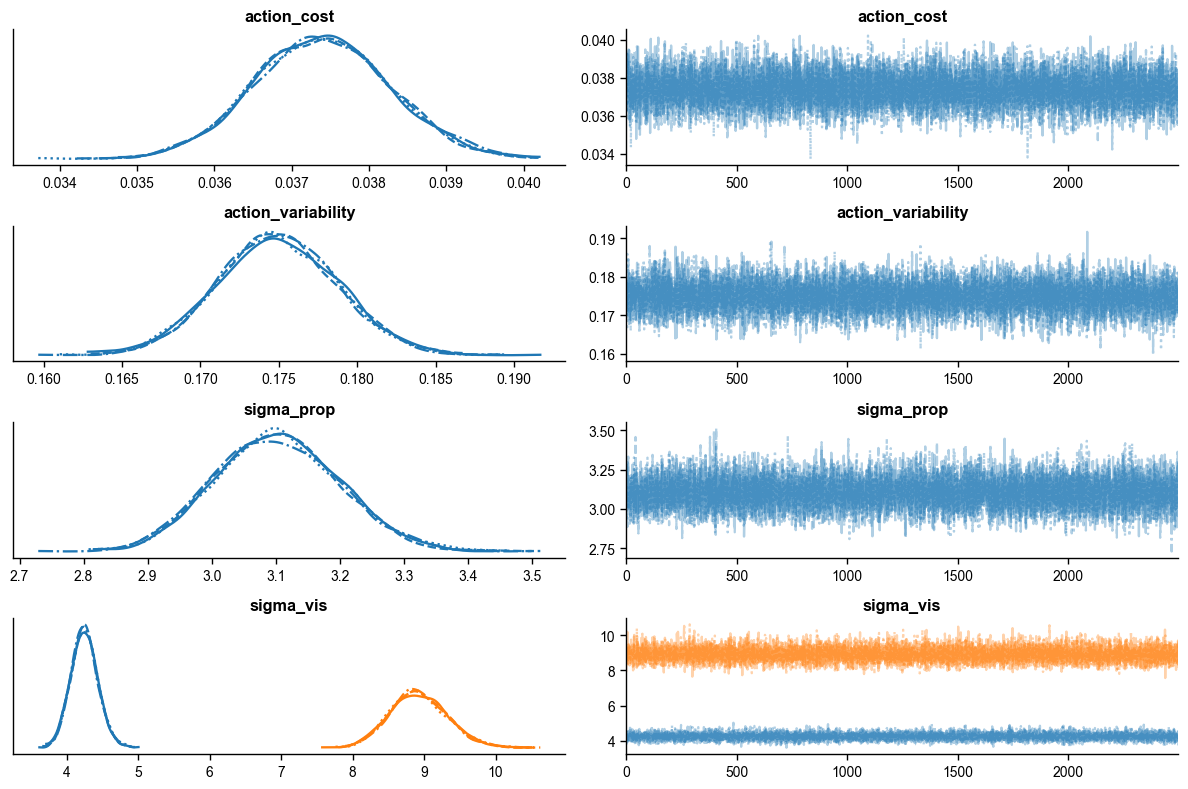

In [18]:
for name, model in models.items():
    az.plot_trace(model)
    plt.tight_layout()

Condition: multi, Vis Noise: 1
{'action_cost': 0.037, 'action_variability': 0.174, 'sigma_prop': 3.086, 'sigma_vis[0]': 5.403, 'sigma_vis[1]': 13.606}
Condition: multi, Vis Noise: 2
{'action_cost': 0.037, 'action_variability': 0.174, 'sigma_prop': 3.086, 'sigma_vis[0]': 5.403, 'sigma_vis[1]': 13.606}
Condition: vis, Vis Noise: 1
{'action_cost': 0.037, 'action_variability': 0.174, 'sigma_prop': 3.086, 'sigma_vis[0]': 5.403, 'sigma_vis[1]': 13.606}
Condition: vis, Vis Noise: 2
{'action_cost': 0.037, 'action_variability': 0.174, 'sigma_prop': 3.086, 'sigma_vis[0]': 5.403, 'sigma_vis[1]': 13.606}
Condition: prop, Vis Noise: 1
{'action_cost': 0.037, 'action_variability': 0.174, 'sigma_prop': 3.086, 'sigma_vis[0]': 5.403, 'sigma_vis[1]': 13.606}
Condition: prop, Vis Noise: 2
{'action_cost': 0.037, 'action_variability': 0.174, 'sigma_prop': 3.086, 'sigma_vis[0]': 5.403, 'sigma_vis[1]': 13.606}
Condition: multi, Vis Noise: 1
{'action_cost': 0.038, 'action_variability': 0.172, 'sigma_prop': 3.0

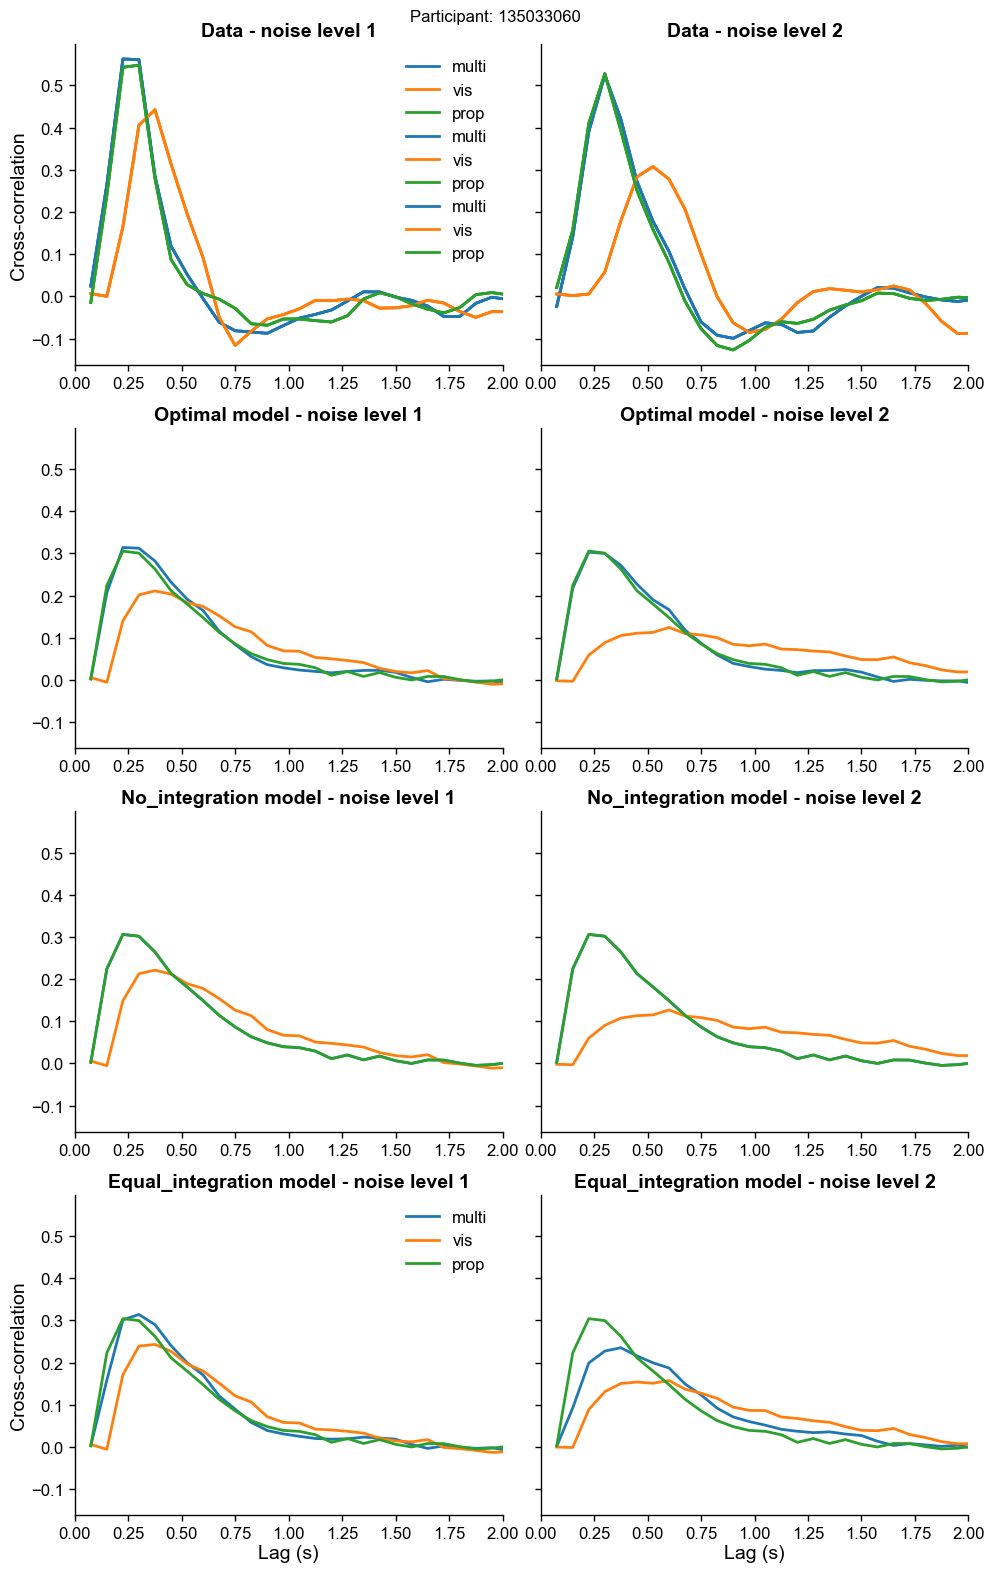

In [24]:
import jax.numpy as jnp

f, ax = plt.subplots(4, 2, figsize=(10, 16), sharey=True)

for k, (model_name, model) in enumerate(models.items()):
    summary = az.summary(model)
    # get posterior mean
    posterior_mean = summary["mean"].to_dict()
    for i, condition in enumerate(["multi", "vis", "prop"]):

        for j, vis_noise in enumerate([1, 2]):
            # preprocess the data for this participant, condition, and noise level
            data = preprocess_multisensory_data(
                    df, participant=participant, condition=condition, vis_noise=vis_noise
                )

            
            print(f"Condition: {condition}, Vis Noise: {vis_noise}")
            print(posterior_mean)

            # create model with posterior mean parameters (note that we have to rename the sigmas parameters for the multisensory model)
            if condition == "multi":
                if model_name == "optimal":
                    model = MultisensoryDelayModel(
                        process_noise=1.2,
                        sigmas=[posterior_mean["sigma_prop"], posterior_mean[f"sigma_vis[{vis_noise - 1}]"]],
                        action_variability=posterior_mean["action_variability"],
                        action_cost=posterior_mean["action_cost"],
                        delays=[delays["prop"], delays["vis"]],
                        dt=0.075,
                        T=data.shape[1],
                    )
                elif model_name == "no_integration":
                    model = UnisensoryDelayModel(
                        process_noise=1.2,
                        sigma=posterior_mean[f"sigma_prop"],
                        action_variability=posterior_mean["action_variability"],
                        action_cost=posterior_mean["action_cost"],
                        delay=delays["prop"],
                        dt=0.075,
                        T=data.shape[1],
                    )
                elif model_name == "equal_integration":
                    sigma = jnp.sqrt((posterior_mean[f"sigma_prop"] ** 2 + posterior_mean[f"sigma_vis[{vis_noise - 1}]"] ** 2) / 2)
                    model = MultisensoryDelayModel(
                        process_noise=1.2,
                        sigmas=[sigma, sigma],
                        action_variability=posterior_mean["action_variability"],
                        action_cost=posterior_mean["action_cost"],
                        delays=[delays["prop"], delays["vis"]],
                        dt=0.075,
                        T=data.shape[1],
                    )
            else:
                delay = delays[condition]
                model = UnisensoryDelayModel(
                    process_noise=1.2,
                    sigma=posterior_mean[f"sigma_{condition}"] if condition == "prop" else posterior_mean[f"sigma_vis[{vis_noise - 1}]"],
                    action_variability=posterior_mean["action_variability"],
                    action_cost=posterior_mean["action_cost"],
                    delay=delay,
                    dt=0.075,
                    T=data.shape[1],
                )

            # TODO: generate prediction for multisensory condition from unisensory model fits

            # simulate data from the model and compute cross-correlation of velocities for both the simulated data and the real data
            sim_data = model.simulate(rng_key=random.PRNGKey(0), n=100)
            sim_vels = np.diff(sim_data, axis=1)
            lags, sim_correls = xcorr(sim_vels[:, :, 1], sim_vels[:, :, 0], maxlags=50)

            
            vels = np.diff(data, axis=1)
            lags, correls = xcorr(vels[:, :, 1], vels[:, :, 0], maxlags=50)

            # plot the cross-correlations for the real data and the simulated data
            ax[0, j].plot(
                lags[51:] * 0.075, correls.mean(axis=0)[51:], label=f"{condition}", color=f"C{i}"
            )
            ax[k+1, j].plot(
                lags[51:] * 0.075, sim_correls.mean(axis=0)[51:], label=f"{condition}", color=f"C{i}"
            )

            ax[0, j].set_xlim(0, 2)
            ax[k+1, j].set_xlim(0, 2)

            ax[0, j].set_title(f"Data - noise level {vis_noise}")
            ax[k+1, j].set_title(f"{model_name.capitalize()} model - noise level {vis_noise}")

ax[k+1, 0].set_xlabel("Lag (s)")
ax[k+1, 1].set_xlabel("Lag (s)")
ax[0, 0].set_ylabel("Cross-correlation")
ax[k+1, 0].set_ylabel("Cross-correlation")

ax[0, 0].legend()
ax[k+1, 0].legend()
f.suptitle(f"Participant: {participant}")
f.tight_layout()